# 06 — 三代方法论对比评估（核心 Notebook）

**这是整个项目的核心结论所在。**

本 Notebook 用统一的评估体系，量化对比三代方法论的效果。
核心问题：
1. 每一代的质量提升是多少？（量化 LIFT）
2. 每一代的数据损失是多少？（保留率）
3. 质量 vs 数量的 trade-off 如何？
4. 对于不同的训练场景，应该选择哪一代？

In [ ]:
# === 环境初始化 + 加载两档三代输出数据 ===
import sys, json, re
sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
import matplotlib.gridspec as gridspec
from pathlib import Path
from src.utils.config_loader import load_run_config, load_eval_config, get_output_path, print_config_summary
from src.utils.io import read_jsonl

# CC WET 文本可能含 surrogate 字符（\ud800-\udfff），必须显式移除
def sanitize_text(text):
    return re.sub(r'[\ud800-\udfff]', '', text)

def sanitize_docs(docs):
    for d in docs:
        if 'text' in d:
            d['text'] = sanitize_text(d['text'])
    return docs

def load_gen_output(gen_num, run_cfg, max_docs=None):
    """加载 pipeline 输出。max_docs=None 表示全量加载（gen 输出已经是过滤后的小数据集）。"""
    output_path = get_output_path(gen_num, run_cfg)
    jsonl_file = output_path / f'gen{gen_num}_output.jsonl'
    if jsonl_file.exists():
        docs = sanitize_docs(read_jsonl(jsonl_file, doc_limit=max_docs))
        print(f"    Gen{gen_num}: {jsonl_file} -> {len(docs):,} docs")
        return docs
    else:
        print(f"    Gen{gen_num}: {jsonl_file} NOT FOUND")
    return None

# --- 依赖文件校验 ---
run_cfg = load_run_config()
current_mode = run_cfg.get('run_mode', 'smoke_test')
REQUIRED_FILES = {}
for gen in [1, 2, 3]:
    gen_dir = get_output_path(gen, run_cfg)
    REQUIRED_FILES[f'Gen{gen} 输出'] = gen_dir / f'gen{gen}_output.jsonl'
for name, path in REQUIRED_FILES.items():
    assert path.exists(), f"缺少 {name}: {path}，请先运行对应的 scripts/run_gen*.py"

# --- 加载两档数据 ---
MODES = ['smoke_test', 'full_run']
dual_docs = {}

for mode in MODES:
    print(f"\n{'='*60}")
    print(f"  加载 {mode} 数据")
    print(f"{'='*60}")
    mode_cfg = load_run_config(run_mode_override=mode)
    eval_sample = mode_cfg.get('eval_sample_size', 200)

    # 原始数据：用 eval_sample 限制（100K 全量打分太慢）
    raw_files = list(Path('../data/raw').glob('*.jsonl'))
    if raw_files:
        raw_docs = sanitize_docs(read_jsonl(raw_files[0], doc_limit=eval_sample))
    else:
        raw_docs = [{'text': f'Raw document {i}: placeholder text. ' * 5} for i in range(eval_sample)]

    # Gen 输出：全量加载（已是过滤后的小数据集，不应截断）
    gen1_docs = load_gen_output(1, mode_cfg)
    gen2_docs = load_gen_output(2, mode_cfg)
    gen3_docs = load_gen_output(3, mode_cfg)

    dual_docs[mode] = {
        'raw': raw_docs,
        'gen1': gen1_docs if gen1_docs else [],
        'gen2': gen2_docs if gen2_docs else [],
        'gen3': gen3_docs if gen3_docs else [],
    }

    print(f"\n  [{mode}] 文档数：Raw={len(dual_docs[mode]['raw'])}（采样上限{eval_sample}）, "
          f"Gen1={len(dual_docs[mode]['gen1'])}（全量）, "
          f"Gen2={len(dual_docs[mode]['gen2'])}（全量）, "
          f"Gen3={len(dual_docs[mode]['gen3'])}（全量）")

# 汇总两档对比
print(f"\n{'='*60}")
print("  两档文档数对比")
print(f"{'='*60}")
print(f"  {'代次':<12} {'smoke_test':>12} {'full_run':>12}")
print(f"  {'-'*36}")
for gen_key in ['raw', 'gen1', 'gen2', 'gen3']:
    s = len(dual_docs['smoke_test'][gen_key])
    f = len(dual_docs['full_run'][gen_key])
    print(f"  {gen_key:<12} {s:>12,} {f:>12,}")

In [2]:
# === 加载/训练独立评估分类器 ===
# 评估分类器与各代 pipeline 内部的分类器独立训练（使用不同的正样本集和超参数），
# 避免"用 pipeline 分类器评估 pipeline 输出"导致的循环偏差。
# 如评估分类器已存在则直接加载，否则用 Wikipedia 摘要作为正样本、
# 原始数据作为负样本重新训练（dim=32, wordNgrams=3）。

# 加载评估分类器
from src.evaluation.quality_classifier import EvalQualityClassifier
from src.evaluation.diversity_metrics import compute_all_ngram_diversities
from src.utils.tokenizer_utils import count_tokens_batch, get_tokenizer

eval_clf = EvalQualityClassifier()
eval_clf_path = '../results/quality_scores/eval_classifier.bin'

if Path(eval_clf_path).exists():
    eval_clf._load(eval_clf_path)
else:
    print("⚠️ 评估分类器未训练，训练中...")
    wiki_texts = []
    wiki_path = Path('../data/reference/wikipedia_abstracts_eval.jsonl')
    if wiki_path.exists():
        with open(wiki_path) as f:
            for i, line in enumerate(f):
                if i >= 1000: break
                try: wiki_texts.append(json.loads(line)['text'])
                except: pass
    if not wiki_texts:
        wiki_texts = ['Scientific knowledge and educational content. ' * 20] * 500
    neg_texts = [d['text'] for d in raw_docs[:len(wiki_texts)]]
    eval_clf.train(wiki_texts[:500], neg_texts[:500], eval_clf_path, dim=32, wordNgrams=3, minCount=5)

print("✅ 评估分类器就绪")

  ✅ 评估分类器已加载: ../results/quality_scores/eval_classifier.bin
✅ 评估分类器就绪


In [3]:
# === 统一评估两档各代数据质量 ===
# 对两档（smoke_test / full_run）的原始数据和三代 pipeline 输出
# 使用相同的评估分类器打分，计算质量分数（均值/P50/P90）、N-gram 多样性、
# 平均 Token 数等指标。每代最多取 200 条计算多样性、100 条计算 Token 数。

tokenizer = get_tokenizer()

def evaluate_generation(docs, name):
    """对一组文档进行质量评估，返回各维度指标。"""
    if not docs:
        return {
            'name': name, 'doc_count': 0,
            'quality_mean': 0.0, 'quality_p50': 0.0, 'quality_p90': 0.0,
            'unigram_diversity': 0.0, 'trigram_diversity': 0.0,
            'avg_tokens': 0.0, 'quality_scores': np.array([]),
        }
    texts = [d['text'] for d in docs]
    scores = eval_clf.score_batch(texts)
    diversity = compute_all_ngram_diversities(texts[:200])
    tokens = count_tokens_batch(texts[:100], tokenizer)
    return {
        'name': name,
        'doc_count': len(docs),
        'quality_mean': float(scores.mean()),
        'quality_p50': float(np.percentile(scores, 50)),
        'quality_p90': float(np.percentile(scores, 90)),
        'unigram_diversity': diversity.get('unigram', {}).get('unique_ratio', 0),
        'trigram_diversity': diversity.get('trigram', {}).get('unique_ratio', 0),
        'avg_tokens': float(np.mean(tokens)) if len(tokens) > 0 else 0.0,
        'quality_scores': scores,
    }

GEN_NAMES = {
    'raw': '原始数据',
    'gen1': '第一代(Heuristic)',
    'gen2': '第二代(Model-based)',
    'gen3': '第三代(Hybrid)',
}

dual_evals = {}

for mode in MODES:
    print(f"\n📊 评估 {mode} 各代数据质量...")
    mode_evals = {}
    for gen_key in ['raw', 'gen1', 'gen2', 'gen3']:
        docs = dual_docs[mode][gen_key]
        mode_evals[gen_key] = evaluate_generation(docs, GEN_NAMES[gen_key])
    dual_evals[mode] = mode_evals
    print(f"  [{mode}] 评估完成:")
    for k, e in mode_evals.items():
        print(f"    {e['name']}: quality_mean={e['quality_mean']:.4f}, docs={e['doc_count']:,}")


📊 评估 smoke_test 各代数据质量...


  [smoke_test] 评估完成:
    原始数据: quality_mean=0.4768, docs=500
    第一代(Heuristic): quality_mean=0.6870, docs=409
    第二代(Model-based): quality_mean=0.8187, docs=41
    第三代(Hybrid): quality_mean=0.7475, docs=205

📊 评估 full_run 各代数据质量...


  [full_run] 评估完成:
    原始数据: quality_mean=0.4715, docs=2,000
    第一代(Heuristic): quality_mean=0.6892, docs=3,242
    第二代(Model-based): quality_mean=0.7931, docs=325
    第三代(Hybrid): quality_mean=0.7490, docs=1,725


In [4]:
# === 数据源监控指标 ===
# 补充三个关键监控维度：垃圾率估算、文档长度分布、质量分离度
# 这些指标用于验证各代数据的健康度，确保 pipeline 没有引入异常

from collections import Counter

print("=" * 70)
print("  数据源监控指标（各代数据健康度检查）")
print("=" * 70)

for mode in MODES:
    print(f"\n{'─' * 60}")
    print(f"  [{mode}]")
    print(f"{'─' * 60}")
    
    evals = dual_evals[mode]
    
    # 1. 垃圾率估算（quality_score < 0.2 的文档占比）
    # 口径：垃圾率 = quality_score < 0.2 的文档数 / 该代总文档数
    print("\n  📊 垃圾率估算（eval 分类器 quality_score < 0.2 的占比）:")
    for gen_key in ['raw', 'gen1', 'gen2', 'gen3']:
        e = evals[gen_key]
        scores = e['quality_scores']
        if len(scores) > 0:
            garbage_count = int((scores < 0.2).sum())
            garbage_rate = garbage_count / len(scores) * 100
            print(f"    {e['name']:20s}: {garbage_rate:5.1f}% ({garbage_count}/{len(scores)})")
        else:
            print(f"    {e['name']:20s}: N/A (无数据)")
    
    # 2. 文档长度分布（词数 P25/P50/P75）
    # 口径：每篇文档的英文单词数（text.split() 统计）
    print("\n  📏 文档长度分布（词数 P25 / P50 / P75）:")
    for gen_key in ['raw', 'gen1', 'gen2', 'gen3']:
        docs = dual_docs[mode][gen_key]
        if docs:
            word_counts = [len(d['text'].split()) for d in docs]
            p25 = int(np.percentile(word_counts, 25))
            p50 = int(np.percentile(word_counts, 50))
            p75 = int(np.percentile(word_counts, 75))
            name = evals[gen_key]['name']
            print(f"    {name:20s}: P25={p25:5d} | P50={p50:5d} | P75={p75:5d} | 总文档={len(docs):,}")
    
    # 3. 质量分离度（P90 - P50）
    # 口径：eval 分类器 quality_score 的 P90 与 P50 之差
    # 健康值：>0.2 表示有意义的质量梯度，>0.3 表示良好区分能力
    print("\n  🔬 质量分离度（P90 - P50, 越大表示质量梯度越明显）:")
    for gen_key in ['raw', 'gen1', 'gen2', 'gen3']:
        e = evals[gen_key]
        scores = e['quality_scores']
        if len(scores) > 0:
            separation = e['quality_p90'] - e['quality_p50']
            health = "✓ 良好" if separation > 0.3 else ("⚠ 偏低" if separation > 0.1 else "✗ 异常")
            print(f"    {e['name']:20s}: {separation:.4f}  {health}  (P90={e['quality_p90']:.4f}, P50={e['quality_p50']:.4f})")
        else:
            print(f"    {e['name']:20s}: N/A")

print(f"\n{'=' * 70}")

  数据源监控指标（各代数据健康度检查）

────────────────────────────────────────────────────────────
  [smoke_test]
────────────────────────────────────────────────────────────

  📊 垃圾率估算（eval 分类器 quality_score < 0.2 的占比）:
    原始数据                :   2.4% (12/500)
    第一代(Heuristic)      :   0.0% (0/409)
    第二代(Model-based)    :   0.0% (0/41)
    第三代(Hybrid)         :   0.0% (0/205)

  📏 文档长度分布（词数 P25 / P50 / P75）:
    原始数据                : P25=  137 | P50=  345 | P75=  809 | 总文档=500
    第一代(Heuristic)      : P25=  235 | P50=  508 | P75= 1066 | 总文档=409
    第二代(Model-based)    : P25=  491 | P50=  871 | P75= 1321 | 总文档=41
    第三代(Hybrid)         : P25=  330 | P50=  683 | P75= 1291 | 总文档=205

  🔬 质量分离度（P90 - P50, 越大表示质量梯度越明显）:
    原始数据                : 0.2032  ⚠ 偏低  (P90=0.6639, P50=0.4608)
    第一代(Heuristic)      : 0.0996  ✗ 异常  (P90=0.7970, P50=0.6975)
    第二代(Model-based)    : 0.0612  ✗ 异常  (P90=0.8725, P50=0.8113)
    第三代(Hybrid)         : 0.0785  ✗ 异常  (P90=0.8310, P50=0.7525)

──────────────────────

    第三代(Hybrid)         : P25=  333 | P50=  723 | P75= 1361 | 总文档=1,725

  🔬 质量分离度（P90 - P50, 越大表示质量梯度越明显）:
    原始数据                : 0.2040  ⚠ 偏低  (P90=0.6626, P50=0.4585)
    第一代(Heuristic)      : 0.1129  ⚠ 偏低  (P90=0.8116, P50=0.6987)
    第二代(Model-based)    : 0.0787  ✗ 异常  (P90=0.8756, P50=0.7970)
    第三代(Hybrid)         : 0.0838  ✗ 异常  (P90=0.8358, P50=0.7520)



In [5]:
# === 双模式核心对比表输出 ===
# 分别展示 smoke_test 和 full_run 两档的三代方法论对比表。
# LIFT = (该代质量均值 - 原始质量均值) / 原始质量均值 × 100%。

def build_comparison_table(evals, mode_label):
    """根据一档评估结果，构建对比表 DataFrame。"""
    baseline_quality = evals['raw']['quality_mean']
    rows = []
    for k, e in evals.items():
        lift = (e['quality_mean'] - baseline_quality) / baseline_quality * 100 if baseline_quality > 0 else 0
        rows.append({
            '代次': e['name'],
            '文档数': f"{e['doc_count']:,}",
            '质量均值': f"{e['quality_mean']:.4f}",
            'LIFT vs 原始': f"+{lift:.1f}%" if lift >= 0 else f"{lift:.1f}%",
            '质量P90': f"{e['quality_p90']:.4f}",
            '3-gram多样性': f"{e['trigram_diversity']:.4f}",
            '平均Token数': f"{e['avg_tokens']:.0f}",
        })
    return pd.DataFrame(rows)

for mode in MODES:
    evals = dual_evals[mode]
    df = build_comparison_table(evals, mode)
    print(f"\n{'='*70}")
    print(f"  三代方法论对比表 — {mode.upper()}（核心结论）")
    print(f"{'='*70}")
    print(df.to_string(index=False))
    print()

# 两档横向对比：同一代次在不同数据规模下的质量差异
print(f"\n{'='*70}")
print(f"  两档横向对比：同一代次在不同数据规模下的质量变化")
print(f"{'='*70}")
print(f"  {'代次':<20} {'smoke_test质量':>14} {'full_run质量':>14} {'差值':>10}")
print(f"  {'-'*58}")
for gen_key in ['raw', 'gen1', 'gen2', 'gen3']:
    s_q = dual_evals['smoke_test'][gen_key]['quality_mean']
    f_q = dual_evals['full_run'][gen_key]['quality_mean']
    diff = f_q - s_q
    name = GEN_NAMES[gen_key]
    print(f"  {name:<20} {s_q:>14.4f} {f_q:>14.4f} {diff:>+10.4f}")


  三代方法论对比表 — SMOKE_TEST（核心结论）
              代次 文档数   质量均值 LIFT vs 原始  质量P90 3-gram多样性 平均Token数
            原始数据 500 0.4768      +0.0% 0.6639    0.7775     3879
  第一代(Heuristic) 409 0.6870     +44.1% 0.7970    0.8861     1537
第二代(Model-based)  41 0.8187     +71.7% 0.8725    0.9499     1515
     第三代(Hybrid) 205 0.7475     +56.8% 0.8310    0.9138     1812


  三代方法论对比表 — FULL_RUN（核心结论）
              代次   文档数   质量均值 LIFT vs 原始  质量P90 3-gram多样性 平均Token数
            原始数据 2,000 0.4715      +0.0% 0.6626    0.7775     3879
  第一代(Heuristic) 3,242 0.6892     +46.1% 0.8116    0.8982     1312
第二代(Model-based)   325 0.7931     +68.2% 0.8756    0.9207     1511
     第三代(Hybrid) 1,725 0.7490     +58.8% 0.8358    0.9161     1492


  两档横向对比：同一代次在不同数据规模下的质量变化
  代次                     smoke_test质量     full_run质量         差值
  ----------------------------------------------------------
  原始数据                         0.4768         0.4715    -0.0052
  第一代(Heuristic)               0.6870         0.6892    +0.00

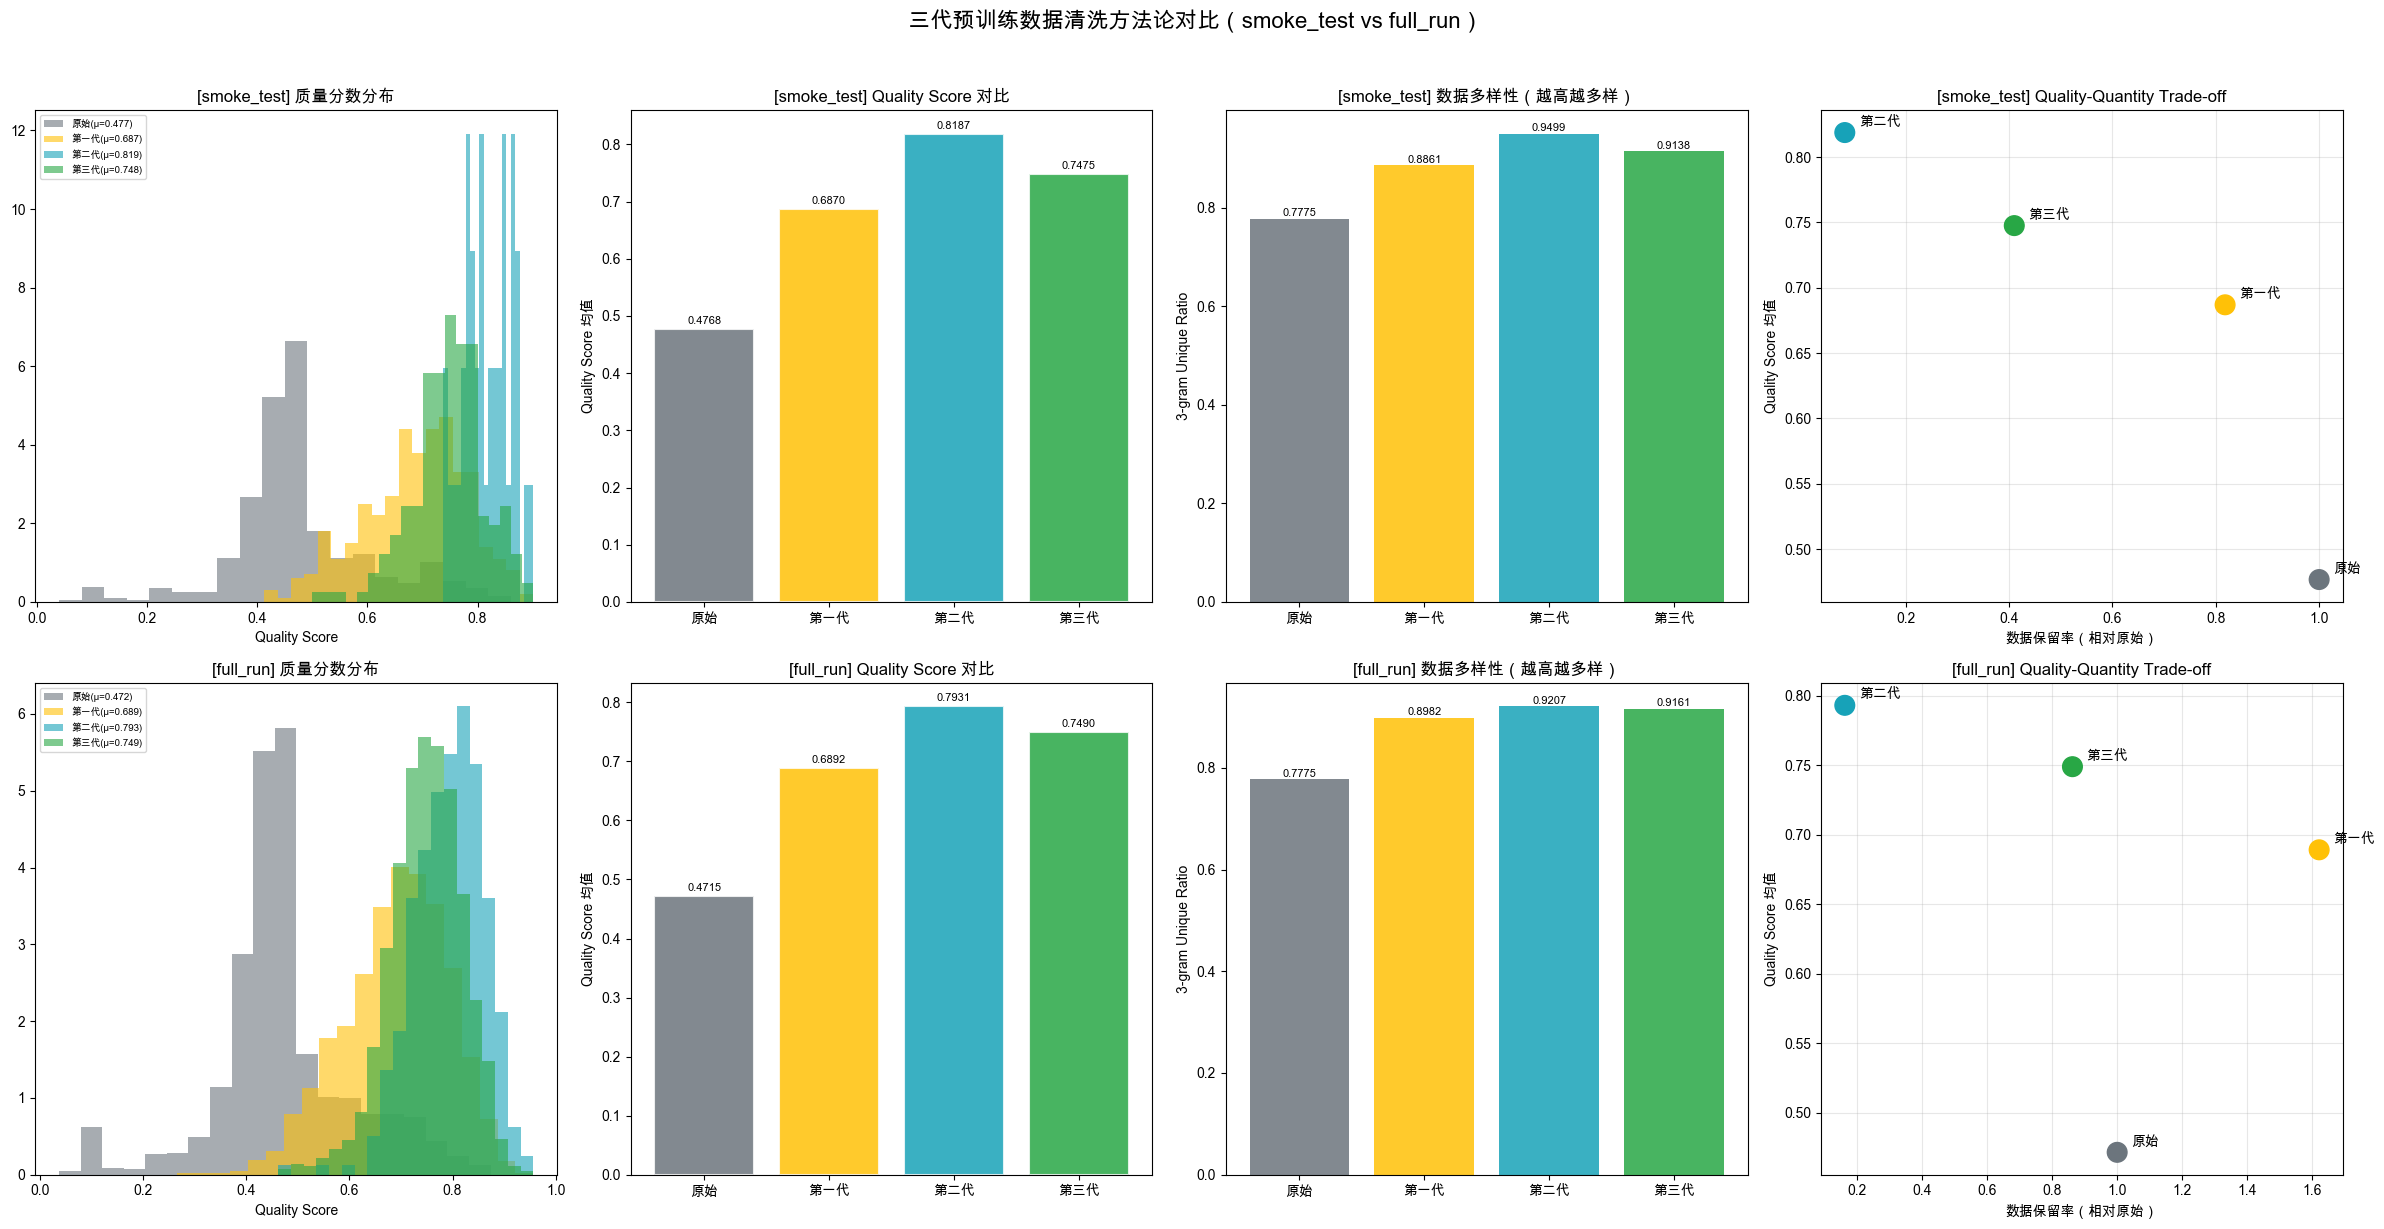

✅ 图表已保存: results/figures/06_cross_generation_comparison.png


In [6]:
# === 2×4 双模式联合可视化 ===
# 上行 4 图：smoke_test（质量分布、均值柱状图、多样性、trade-off）
# 下行 4 图：full_run 同样 4 图
# 直观对比两档数据规模下三代方法论的表现差异。

gen_colors = {'raw': '#6c757d', 'gen1': '#ffc107', 'gen2': '#17a2b8', 'gen3': '#28a745'}
gen_labels = {'raw': '原始', 'gen1': '第一代', 'gen2': '第二代', 'gen3': '第三代'}

fig, axes = plt.subplots(2, 4, figsize=(24, 12))

for row_idx, mode in enumerate(MODES):
    evals = dual_evals[mode]
    ax_row = axes[row_idx]

    # --- 列 0：质量分数分布直方图 ---
    for k, e in evals.items():
        if e['doc_count'] > 0:
            ax_row[0].hist(e['quality_scores'], bins=20, alpha=0.6,
                           label=f"{gen_labels[k]}(μ={e['quality_mean']:.3f})",
                           color=gen_colors[k], density=True)
    ax_row[0].set_xlabel('Quality Score')
    ax_row[0].set_title(f'[{mode}] 质量分数分布', fontweight='bold')
    ax_row[0].legend(fontsize=7)

    # --- 列 1：Quality Score 均值柱状图 ---
    gen_keys_present = [k for k in evals if evals[k]['doc_count'] > 0]
    names = [gen_labels[k] for k in gen_keys_present]
    quality_means = [evals[k]['quality_mean'] for k in gen_keys_present]
    colors = [gen_colors[k] for k in gen_keys_present]
    bars = ax_row[1].bar(names, quality_means, color=colors, alpha=0.85,
                         edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, quality_means):
        ax_row[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                       f'{val:.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax_row[1].set_ylabel('Quality Score 均值')
    ax_row[1].set_title(f'[{mode}] Quality Score 对比', fontweight='bold')

    # --- 列 2：3-gram 多样性柱状图 ---
    diversity_vals = [evals[k]['trigram_diversity'] for k in gen_keys_present]
    bars2 = ax_row[2].bar(names, diversity_vals, color=colors, alpha=0.85)
    for bar, val in zip(bars2, diversity_vals):
        ax_row[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                       f'{val:.4f}', ha='center', va='bottom', fontsize=8)
    ax_row[2].set_ylabel('3-gram Unique Ratio')
    ax_row[2].set_title(f'[{mode}] 数据多样性（越高越多样）', fontweight='bold')

    # --- 列 3：Quality-Quantity Trade-off 散点图 ---
    raw_count = evals['raw']['doc_count'] if evals['raw']['doc_count'] > 0 else 1
    retention_rates = [evals[k]['doc_count'] / raw_count for k in gen_keys_present]
    quality_vals = [evals[k]['quality_mean'] for k in gen_keys_present]
    scatter_colors = [gen_colors[k] for k in gen_keys_present]

    ax_row[3].scatter(retention_rates, quality_vals, c=scatter_colors, s=200, zorder=5)
    for i, k in enumerate(gen_keys_present):
        ax_row[3].annotate(gen_labels[k],
                           (retention_rates[i], quality_vals[i]),
                           textcoords='offset points', xytext=(10, 5), fontsize=10)
    ax_row[3].set_xlabel('数据保留率（相对原始）')
    ax_row[3].set_ylabel('Quality Score 均值')
    ax_row[3].set_title(f'[{mode}] Quality-Quantity Trade-off', fontweight='bold')
    ax_row[3].grid(True, alpha=0.3)

plt.suptitle('三代预训练数据清洗方法论对比（smoke_test vs full_run）',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
Path('../results/figures').mkdir(parents=True, exist_ok=True)
plt.savefig('../results/figures/06_cross_generation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 图表已保存: results/figures/06_cross_generation_comparison.png")

## Cell Group F: 最终结论

### 每一代的适用场景

| 场景 | 推荐选择 | 原因 |
|---|---|---|
| 快速基线验证 | 第一代 | 无需训练，10分钟内可用 |
| 短 token horizon（<5T token）训练 | 第二代 | 最高质量，数据量够用 |
| 长 token horizon（15T+ token）训练 | 第三代 | 高质量+足够多的 unique token |
| 资源受限（无 API Key）| 第一代 + 第二代 | 无需 LLM API |

### 对 TikTok 内容安全场景的启示

1. **数据质量 vs 数量的 trade-off 在任何 ML 任务中都存在**：
   TikTok 内容审核的训练数据同样面临这个问题——
   高精度标注数据少（贵），弱标注数据多（量大但噪声多）。
   
2. **分类器集成是提升 recall 的通用手段**：
   单一内容安全分类器会有漏判，多分类器 union 能扩大覆盖面。
   
3. **合成数据改写 ≈ 数据增强**：
   对于罕见的有害内容类型（数据稀少），LLM 改写/合成是获取更多训练数据的可行方案。

In [7]:
# === 保存两档对比结果为 JSON ===
# 将 smoke_test 和 full_run 两档的各代评估指标序列化为 JSON 文件，
# 存储到 results/reports/ 目录下，供报告生成脚本和项目展示使用。

import json

comparison_results = {}
for mode in MODES:
    mode_result = {}
    for k, e in dual_evals[mode].items():
        mode_result[k] = {k2: v for k2, v in e.items() if k2 != 'quality_scores'}
    comparison_results[mode] = mode_result

Path('../results/reports').mkdir(parents=True, exist_ok=True)
output_json = '../results/reports/cross_generation_comparison.json'
with open(output_json, 'w') as f:
    json.dump(comparison_results, f, ensure_ascii=False, indent=2, default=float)

print(f"✅ 两档对比结果已保存: {output_json}")
print(f"   JSON 结构: {list(comparison_results.keys())}")
for mode in MODES:
    print(f"   [{mode}] 包含代次: {list(comparison_results[mode].keys())}")

✅ 两档对比结果已保存: ../results/reports/cross_generation_comparison.json
   JSON 结构: ['smoke_test', 'full_run']
   [smoke_test] 包含代次: ['raw', 'gen1', 'gen2', 'gen3']
   [full_run] 包含代次: ['raw', 'gen1', 'gen2', 'gen3']
